In [13]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


# Paths
PROJECT_ROOT = Path('../..').resolve()
BI_ADDERS = PROJECT_ROOT / '01_data' / '2_cleaned' / 'price_adders' / 'price_adders_hourly_20200101_20251204.csv'
RTM_PRICE = PROJECT_ROOT / '01_data' / '2_cleaned' / 'rtm_price' / "rtm_price_aggregated_2021_2025.csv"
OUT_DIR = PROJECT_ROOT / '01_data' / '3_analysis' / 'price_adders_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [14]:
# import datasets
df_price_adders = pd.read_csv(BI_ADDERS)
df_price_rtm = pd.read_csv(RTM_PRICE)

In [15]:
df_price_rtm

,date_time,avg_rtm_price,std_rtm_price
0,2021-01-01 01:00:00,18.714000,1.508854
1,2021-01-01 02:00:00,18.107333,1.512517
2,2021-01-01 03:00:00,17.570000,1.537424
3,2021-01-01 04:00:00,17.670667,1.540869
4,2021-01-01 05:00:00,17.792000,1.997417
...,...,...,...
43310,2025-12-27 20:00:00,17.682000,4.066851
43311,2025-12-27 21:00:00,15.002667,4.357721
43312,2025-12-27 22:00:00,13.227333,4.750020
43313,2025-12-27 23:00:00,14.328667,5.222993


In [16]:
# RTM price series is already system-wide averaged (avg_rtm_price, from 00_rtm_price_eda);
# rename for downstream use and flag spike hours
df_price_spike = df_price_rtm.rename(columns={'avg_rtm_price': 'price'})[['date_time', 'price']].copy()

# is_spike is when price is over 1000
df_price_spike['is_spike'] = (df_price_spike['price'] > 1000).astype(int)
print(f'count of spike hours: {df_price_spike["is_spike"].sum()}')

# spike_hours uses hour-ending convention (01:00 = midnight–1am interval)
# price_adders uses hour-starting convention (00:00 = midnight–1am interval)
# shift spike timestamps back 1 hour to align before merging
df_price_spike['date_time'] = pd.to_datetime(df_price_spike['date_time']) - pd.Timedelta(hours=1)
df_price_spike

count of spike hours: 252


,date_time,price,is_spike
0,2021-01-01 00:00:00,18.714000,0
1,2021-01-01 01:00:00,18.107333,0
2,2021-01-01 02:00:00,17.570000,0
3,2021-01-01 03:00:00,17.670667,0
4,2021-01-01 04:00:00,17.792000,0
...,...,...,...
43310,2025-12-27 19:00:00,17.682000,0
43311,2025-12-27 20:00:00,15.002667,0
43312,2025-12-27 21:00:00,13.227333,0
43313,2025-12-27 22:00:00,14.328667,0


In [17]:
# if any adder is active
cols = df_price_adders.columns.difference(['datetime'])
df_price_adders['if_adder'] = df_price_adders[cols].any(axis=1)
df_price_adders

,datetime,RTRSVPOR,RTRSVPOFF,RTRDP,if_adder
0,2020-01-01 00:00:00,0.0,0.0,0.0,False
1,2020-01-01 01:00:00,0.0,0.0,0.0,False
2,2020-01-01 02:00:00,0.0,0.0,0.0,False
3,2020-01-01 03:00:00,0.0,0.0,0.0,False
4,2020-01-01 04:00:00,0.0,0.0,0.0,False
...,...,...,...,...,...
51925,2025-12-03 19:00:00,0.0,0.0,0.0,False
51926,2025-12-03 20:00:00,0.0,0.0,0.0,False
51927,2025-12-03 21:00:00,0.0,0.0,0.0,False
51928,2025-12-03 22:00:00,0.0,0.0,0.0,False


In [18]:
# merge two frames
df_price_adders['datetime'] = pd.to_datetime(df_price_adders['datetime'])
df = pd.merge(df_price_adders, df_price_spike, left_on='datetime', right_on='date_time', how='right')
df_match = df.drop(columns=['date_time']).rename(columns={'datetime': 'date'})
df_match

,date,RTRSVPOR,RTRSVPOFF,RTRDP,if_adder,price,is_spike
0,2021-01-01 00:00:00,0.0,0.0,0.0,False,18.714000,0
1,2021-01-01 01:00:00,0.0,0.0,0.0,False,18.107333,0
2,2021-01-01 02:00:00,0.0,0.0,0.0,False,17.570000,0
3,2021-01-01 03:00:00,0.0,0.0,0.0,False,17.670667,0
4,2021-01-01 04:00:00,0.0,0.0,0.0,False,17.792000,0
...,...,...,...,...,...,...,...
43310,NaT,NaN,NaN,NaN,NaN,17.682000,0
43311,NaT,NaN,NaN,NaN,NaN,15.002667,0
43312,NaT,NaN,NaN,NaN,NaN,13.227333,0
43313,NaT,NaN,NaN,NaN,NaN,14.328667,0


In [19]:
df_before2025dec = df_match[df_match['date'] < '2025-12-05']
df_before2025dec = df_before2025dec[['date', 'price', 'RTRSVPOR', 'RTRSVPOFF', 'RTRDP']]
df_before2025dec.to_csv(OUT_DIR / 'price_adders_activation_analysis.csv', index=False)
df_before2025dec

,date,price,RTRSVPOR,RTRSVPOFF,RTRDP
0,2021-01-01 00:00:00,18.714000,0.0,0.0,0.0
1,2021-01-01 01:00:00,18.107333,0.0,0.0,0.0
2,2021-01-01 02:00:00,17.570000,0.0,0.0,0.0
3,2021-01-01 03:00:00,17.670667,0.0,0.0,0.0
4,2021-01-01 04:00:00,17.792000,0.0,0.0,0.0
...,...,...,...,...,...
42734,2025-12-03 19:00:00,44.334667,0.0,0.0,0.0
42735,2025-12-03 20:00:00,38.510667,0.0,0.0,0.0
42736,2025-12-03 21:00:00,32.500667,0.0,0.0,0.0
42737,2025-12-03 22:00:00,32.682000,0.0,0.0,0.0


### plot activation % by price percentile bins

In [20]:
##### change these parameters #####

# for number of bins (e.g., 20 for 5% quantiles, 100 for 1% quantiles)
bin_num = 100

# OPTIONAL: for how many bins to display in the plot (e.g., 10 for last 10 bins, 20 for last 20 bins)
last_bins = 10

###################################

In [21]:
# bin by percentile
df_before2025dec['price_quantile_bin'] = pd.qcut(df_before2025dec['price'], q=bin_num)
df_bins = df_before2025dec[['date', 'price', 'price_quantile_bin', 'RTRSVPOR', 'RTRSVPOFF', 'RTRDP']]
df_bins['Adder Sum'] = df_bins['RTRSVPOR'] + df_bins['RTRSVPOFF'] + df_bins['RTRDP']

# binary "was this adder active this hour" indicators — activation rate is the % of hours
# an adder was active, not the mean dollar value of the adder (which is unbounded and was
# previously being scaled by 100 as if it were already a 0-1 fraction)
adder_columns = ['RTRSVPOR', 'RTRSVPOFF', 'RTRDP', 'Adder Sum']
for col in adder_columns:
    df_bins[f'{col}_active'] = (df_bins[col] != 0).astype(int)
df_bins.head()

,date,price,price_quantile_bin,RTRSVPOR,RTRSVPOFF,RTRDP,Adder Sum,RTRSVPOR_active,RTRSVPOFF_active,RTRDP_active,Adder Sum_active
0,2021-01-01 00:00:00,18.714000,"(18.609, 18.894]",0.0,0.0,0.0,0.0,0,0,0,0
1,2021-01-01 01:00:00,18.107333,"(18.035, 18.316]",0.0,0.0,0.0,0.0,0,0,0,0
2,2021-01-01 02:00:00,17.570000,"(17.436, 17.742]",0.0,0.0,0.0,0.0,0,0,0,0
3,2021-01-01 03:00:00,17.670667,"(17.436, 17.742]",0.0,0.0,0.0,0.0,0,0,0,0
4,2021-01-01 04:00:00,17.792000,"(17.742, 18.035]",0.0,0.0,0.0,0.0,0,0,0,0


In [22]:
# create activation rate table (% of hours each adder was active, per price bin)
active_columns = [f'{col}_active' for col in adder_columns]
activation_rate_table = df_bins.groupby('price_quantile_bin')[active_columns].mean().reset_index()
activation_rate_table.columns = ['price_quantile_bin'] + adder_columns
activation_rate_table

,price_quantile_bin,RTRSVPOR,RTRSVPOFF,RTRDP,Adder Sum
0,"(-2.658, 4.128]",0.000000,0.000000,0.028037,0.028037
1,"(4.128, 6.631]",0.000000,0.000000,0.065574,0.065574
2,"(6.631, 8.225]",0.002336,0.000000,0.077103,0.079439
3,"(8.225, 9.412]",0.002342,0.000000,0.072600,0.074941
4,"(9.412, 10.405]",0.002342,0.000000,0.072600,0.074941
...,...,...,...,...,...
95,"(104.325, 117.115]",0.426230,0.304450,0.533958,0.683841
96,"(117.115, 143.253]",0.491803,0.400468,0.545667,0.716628
97,"(143.253, 205.163]",0.605140,0.528037,0.488318,0.735981
98,"(205.163, 429.983]",0.665105,0.641686,0.407494,0.754098


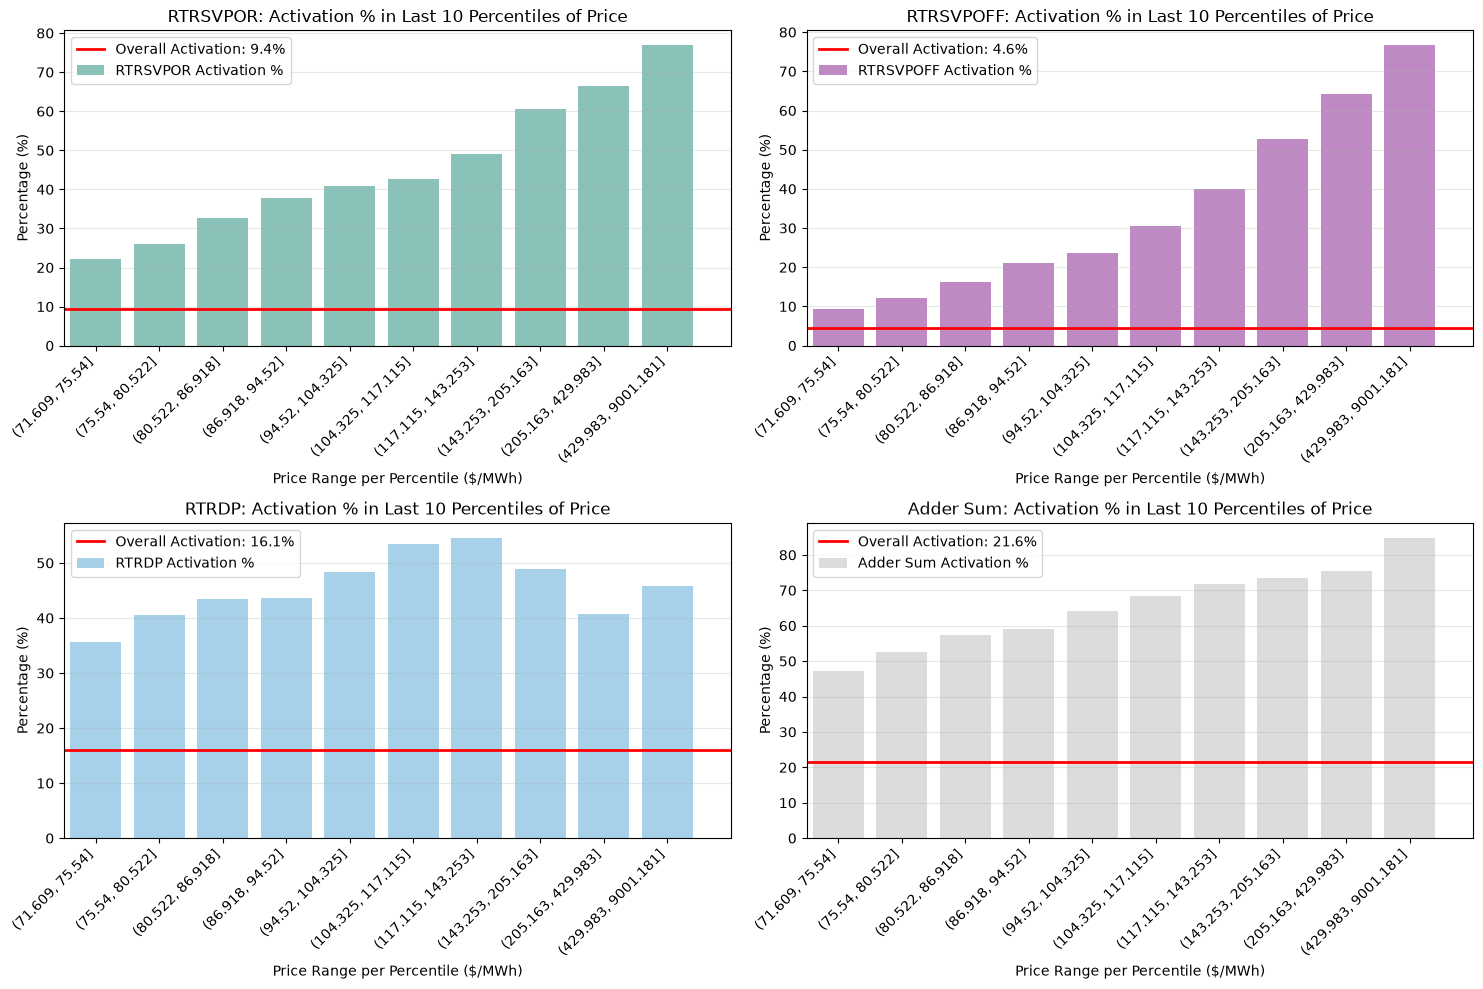

In [23]:
colors = ['#59a89c', "#a559aa9f", "#80bedf", '#cecece']

# baseline = overall % of hours each adder was active (mean of the 0/1 indicator, not the raw value)
baseline = [df_bins[f'{col}_active'].mean() * 100 for col in adder_columns]

# Create separate subplots for each adder type
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
positions = activation_rate_table['price_quantile_bin'].astype(str)

for i, col in enumerate(adder_columns):
    ax_i = axes[i // 2, i % 2]
    
    # Plot adder activation percentage
    ax_i.bar(positions, activation_rate_table[col] * 100, color=colors[i], alpha=0.7, label=f'{col} Activation %')
    
    # Add baseline line (overall spike percentage)
    ax_i.axhline(y=baseline[i], color='red', linestyle='-', linewidth=2, label=f'Overall Activation: {baseline[i]:.1f}%')
    
    ax_i.set_xlabel('Price Range per Percentile ($/MWh)')
    ax_i.set_ylabel('Percentage (%)')
    ax_i.set_title(f'{col}: Activation % in Last {last_bins} Percentiles of Price')
    ax_i.set_xticks(positions)
    ax_i.set_xticklabels(positions, rotation=45, ha='right')
    ax_i.set_xlim(len(positions)-last_bins-0.5, len(positions))
    ax_i.legend(loc='upper left')
    ax_i.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/price_adder_last_{last_bins}_{100/bin_num}_percentiles.png', dpi=300, bbox_inches='tight')
plt.show()